# Dynamic Routing tutorial: behavior, one unit, and covariates

This notebook is a worked tour through one Allen Institute Dynamic Routing ephys session: `713655_2024-08-09`. It is written for trainee neuroscientists who know basic Python but are new to NWB, `lazynwb`, and this task.

The main neural example is unit `713655_2024-08-09_E-167`, a CP unit that passes QC, passes the low-drift filter, and has `activity_drift` close to 0.0516. The analysis is intentionally compact: load only the columns needed for each question, keep the Polars transformations visible, and interpret plots as teaching examples rather than publication-ready figures.


## Dataset and task context

The capsule contains five Neuropixels Dynamic Routing sessions. Each session includes a main `DynamicRouting1` behavior epoch in which the mouse switches between visual-rewarded and auditory-rewarded blocks. The task uses four named stimuli plus catch trials:

- `vis1`: visual target
- `sound1`: auditory target
- `vis2`: visual non-target
- `sound2`: auditory non-target
- `catch`: no visual or auditory stimulus

In visual-rewarded blocks the animal should respond to `vis1` and withhold responses to the other stimuli. In auditory-rewarded blocks the animal should respond to `sound1` and withhold responses to the other stimuli. Each context-switching task session normally has six blocks, and each block begins with instruction trials that make the new rewarded target available for non-contingent reward.


In [1]:
from __future__ import annotations

import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

sys.path.insert(0, str(pathlib.Path.cwd()))
sys.path.insert(0, str(pathlib.Path.cwd() / "code"))

import nwb_access
import unit_raster_psth_plot

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

SESSION_ID = "713655_2024-08-09"
UNIT_ID = "713655_2024-08-09_E-167"

ALLEN = {
    "black": "#000000",
    "white": "#FFFFFF",
    "gray2": "#737373",
    "page2": "#DED9D1",
    "blue": "#6464FF",
    "maroon": "#CD0F55",
}
CONTEXT_COLORS = {"vis": ALLEN["blue"], "aud": ALLEN["maroon"]}

plt.rcParams.update(
    {
        "figure.facecolor": ALLEN["white"],
        "axes.facecolor": ALLEN["white"],
        "axes.edgecolor": ALLEN["black"],
        "axes.labelcolor": ALLEN["black"],
        "xtick.color": ALLEN["gray2"],
        "ytick.color": ALLEN["gray2"],
        "grid.color": ALLEN["page2"],
        "text.color": ALLEN["black"],
        "font.family": ["Allen Institute Text", "Arial", "sans-serif"],
        "font.size": 9,
    }
)

pl.Config.set_tbl_rows(12)


polars.config.Config

## Find the Zarr assets

`code/assets_zarr.json` records the mounted Code Ocean asset names and their cloud Zarr paths. The local helper resolves a session ID to either the mounted file, when present, or the S3 URI.


In [2]:
zarr_assets = (
    pl.DataFrame(nwb_access.load_assets(zarr=True))
    .with_columns(
        session_id=pl.col("nwb_path").str.extract(r"([^/]+)\.nwb\.zarr$", 1)
    )
    .select("session_id", "mount", "nwb_path")
)

session_nwb_path = nwb_access.get_session_nwb_path(SESSION_ID, zarr=True)
print(f"Using {SESSION_ID}: {session_nwb_path}")
zarr_assets


Using 713655_2024-08-09: s3://codeocean-s3datasetsbucket-1u41qdg42ur9/df845413-afd9-4216-a830-ce016b4a348c/713655_2024-08-09.nwb.zarr


session_id,mount,nwb_path
str,str,str
"""664851_2023-11-15""","""ecephys_664851_2023-11-15_12-3…","""s3://codeocean-s3datasetsbucke…"
"""759434_2025-02-04""","""ecephys_759434_2025-02-04_12-2…","""s3://codeocean-s3datasetsbucke…"
"""742903_2024-10-22""","""ecephys_742903_2024-10-22_10-5…","""s3://codeocean-s3datasetsbucke…"
"""668755_2023-08-31""","""ecephys_668755_2023-08-31_12-3…","""s3://codeocean-s3datasetsbucke…"
"""713655_2024-08-09""","""ecephys_713655_2024-08-09_10-4…","""s3://codeocean-s3datasetsbucke…"


## Scan a table lazily

`nwb_access.scan_table(...)` is a thin project helper around `lazynwb.scan_nwb(...)`. It keeps the notebook readable while preserving the important access pattern: filter and select before `collect()` so large arrays, especially spike vectors, are not loaded by accident.


In [3]:
trial_preview = (
    nwb_access.scan_table("/intervals/trials", session_id=SESSION_ID)
    .select(
        [
            "trial_index",
            "block_index",
            "trial_index_in_block",
            "stim_name",
            "rewarded_modality",
            "is_instruction",
            "is_reward_scheduled",
            "is_response",
            "response_time",
        ]
    )
    .head(8)
    .collect()
)

trial_preview


trial_index,block_index,trial_index_in_block,stim_name,rewarded_modality,is_instruction,is_reward_scheduled,is_response,response_time
i64,i64,f64,str,str,bool,bool,bool,f64
0,0,0.0,"""sound1""","""aud""",true,true,true,2405.46553
1,0,1.0,"""sound1""","""aud""",true,true,true,2411.73257
2,0,2.0,"""sound1""","""aud""",true,true,true,2420.03365
3,0,3.0,"""sound1""","""aud""",true,true,true,2431.43076
4,0,4.0,"""sound1""","""aud""",true,true,true,2437.60187
5,0,5.0,"""vis1""","""aud""",false,false,true,2443.54499
6,0,6.0,"""vis1""","""aud""",false,false,false,NaN
7,0,7.0,"""sound2""","""aud""",false,false,true,2456.10614


## PyNWB/Zarr reference snippet

This tutorial uses `lazynwb` in runnable cells. If you need a full PyNWB object instead, the access pattern is conceptually:

```python
# Reference only: not run in this notebook.
from hdmf_zarr import NWBZarrIO

with NWBZarrIO(session_nwb_path, mode="r", load_namespaces=True) as io:
    nwbfile = io.read()
    trials = nwbfile.intervals["trials"]
```

For this tutorial, table scans are faster to teach and make it easier to avoid loading more data than needed.


## Selected trial column descriptions

NWB columns carry useful descriptions in their metadata. The helper below reads those descriptions without reading the table data.


In [4]:
TRIAL_DESCRIPTION_COLUMNS = (
    "block_index",
    "stim_name",
    "rewarded_modality",
    "is_instruction",
    "is_reward_scheduled",
    "is_response",
    "is_hit",
    "is_false_alarm",
    "is_catch",
    "stim_start_time",
    "response_time",
    "response_window_start_time",
    "response_window_stop_time",
    "quiescent_start_time",
    "quiescent_stop_time",
)

trial_column_descriptions = nwb_access.get_table_column_descriptions(
    "/intervals/trials",
    session_id=SESSION_ID,
    columns=TRIAL_DESCRIPTION_COLUMNS,
)

trial_column_descriptions


{'block_index': '0-indexed block number, increments with each block',
 'stim_name': 'the stimulus presented; corresponds to a unique stimulus definition, randomized over trials',
 'rewarded_modality': 'indicates the name of the rewarded modality in each block; not an exact correspondence with the values in `stim_name`',
 'is_instruction': 'the stimulus presented was not random, but specifically chosen to inform the subject of a change in the rewarded stimulus modality (context)',
 'is_reward_scheduled': 'a non-contingent reward was scheduled to occur, regardless of whether it was delivered; the subject may have responded correctly and received a contingent reward instead',
 'is_response': 'the subject licked one or more times during the response window',
 'is_hit': 'the subject responded in a GO trial',
 'is_false_alarm': 'the subject responded in a NOGO trial; excludes catch trials',
 'is_catch': 'no stimulus was presented',
 'stim_start_time': 'onset of visual or auditory stimulus',


## Collect the trial columns used below

The task logic is all in `/intervals/trials`. We collect one session and a focused set of scalar columns, then reuse that small in-memory table for the behavior plots.


In [ ]:
TRIAL_COLUMNS = [
    "trial_index",
    "block_index",
    "trial_index_in_block",
    "stim_name",
    "rewarded_modality",
    "is_instruction",
    "is_reward_scheduled",
    "is_noncontingent_reward",
    "is_response",
    "is_hit",
    "is_correct_reject",
    "is_false_alarm",
    "is_miss",
    "is_catch",
    "is_vis_stim",
    "is_aud_stim",
    "is_vis_target",
    "is_aud_target",
    "is_go",
    "is_nogo",
    "is_opto",
    "start_time",
    "stop_time",
    "stim_start_time",
    "stim_stop_time",
    "quiescent_start_time",
    "quiescent_stop_time",
    "response_window_start_time",
    "response_window_stop_time",
    "response_time",
]

trials = (
    nwb_access.scan_table("/intervals/trials", session_id=SESSION_ID)
    .select(TRIAL_COLUMNS)
    .collect()
)

block_summary = (
    trials.group_by("block_index", "rewarded_modality")
    .agg(
        pl.len().alias("n_trials"),
        pl.col("is_instruction").sum().alias("n_instruction_trials"),
        pl.col("is_reward_scheduled").sum().alias("n_scheduled_rewards"),
        pl.col("is_noncontingent_reward").sum().alias("n_noncontingent_rewards"),
        pl.col("is_opto").sum().alias("n_opto_trials"),
        pl.col("start_time").min().alias("start_time"),
        pl.col("stop_time").max().alias("stop_time"),
    )
    .sort("block_index")
    .with_columns(duration_min=(pl.col("stop_time") - pl.col("start_time")) / 60)
)

block_summary


block_index,rewarded_modality,n_trials,n_instruction_trials,n_scheduled_rewards,n_noncontingent_rewards,n_opto_trials,start_time,stop_time,duration_min
i64,str,u32,u32,u32,u32,u32,f64,f64,f64
0,"""aud""",77,5,5,0,0,2403.42415,3006.81307,10.056482
1,"""vis""",92,5,5,1,0,3007.69716,3612.55396,10.080947
2,"""aud""",91,5,5,1,0,3613.53811,4219.31238,10.096238
3,"""vis""",80,5,5,1,0,4219.69602,4997.68123,12.96642
4,"""aud""",86,5,5,1,0,4998.73203,5603.03837,10.071772
5,"""vis""",89,5,5,1,0,5603.67233,6205.74332,10.034516


## Block summary

The colored bars encode only the rewarded context: visual-rewarded blocks are Allen blue and auditory-rewarded blocks are Allen maroon. Block 0 is shown at the top so the vertical order matches the session order. Instruction trials are shown as light-green spans, and black ticks mark actual non-contingent rewards; scheduled rewards that were preempted by a correct lick are not ticked.


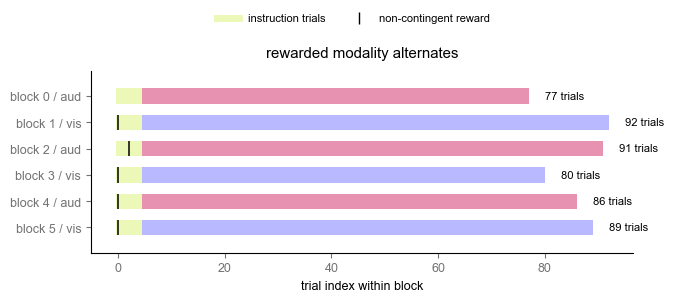

In [34]:
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(7, 2.8))
instruction_color = "#ECF8B8"
bar_height = 0.58

for row in block_summary.iter_rows(named=True):
    block = row["block_index"]
    context = row["rewarded_modality"]
    n_trials = row["n_trials"]
    block_trials = trials.filter(pl.col("block_index") == block)

    ax.add_patch(
        Rectangle(
            (0, block - bar_height / 2),
            n_trials,
            bar_height,
            facecolor=CONTEXT_COLORS[context],
            edgecolor="none",
            alpha=0.45,
            zorder=1,
        )
    )

    instruction_x = block_trials.filter(pl.col("is_instruction"))[
        "trial_index_in_block"
    ].to_numpy()
    noncontingent_x = block_trials.filter(pl.col("is_noncontingent_reward"))[
        "trial_index_in_block"
    ].to_numpy()

    if len(instruction_x):
        x0 = instruction_x.min() - 0.5
        width = instruction_x.max() - instruction_x.min() + 1
        ax.add_patch(
            Rectangle(
                (x0, block - bar_height / 2),
                width,
                bar_height,
                facecolor=instruction_color,
                edgecolor="none",
                zorder=2,
            )
        )

    if len(noncontingent_x):
        ax.vlines(
            noncontingent_x,
            block - bar_height / 2,
            block + bar_height / 2,
            color="black",
            linewidth=1.1,
            zorder=3,
        )

    ax.text(n_trials + 3, block, f"{n_trials} trials", va="center", fontsize=8)

ax.set_yticks(block_summary["block_index"].to_list())
ax.set_yticklabels(
    [
        f"block {block} / {modality}"
        for block, modality in block_summary.select(
            "block_index", "rewarded_modality"
        ).iter_rows()
    ]
)
ax.invert_yaxis()
ax.set_xlabel("trial index within block")
ax.set_title("rewarded modality alternates", pad=10)
fig.legend(
    handles=[
        Line2D([], [], color=instruction_color, lw=5, label="instruction trials"),
        Line2D([], [], color="black", marker="|", linestyle="none", markersize=9, label="non-contingent reward"),
    ],
    frameon=False,
    fontsize=8,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=2,
    borderaxespad=0,
)
ax.margins(y=0.12)
ax.spines[["top", "right"]].set_visible(False)
fig.subplots_adjust(top=0.76)
plt.show()


## Trial timing and response times

This plot summarizes timing relative to stimulus onset. The shaded intervals show mean quiescent, stimulus, and response-window timing from the trial table; each interval is labeled directly with a pointer instead of using a crowded legend. Response markers include visual and auditory stimuli only, excluding catch trials. Marker shape encodes stimulus modality, and vertical position encodes outcome.


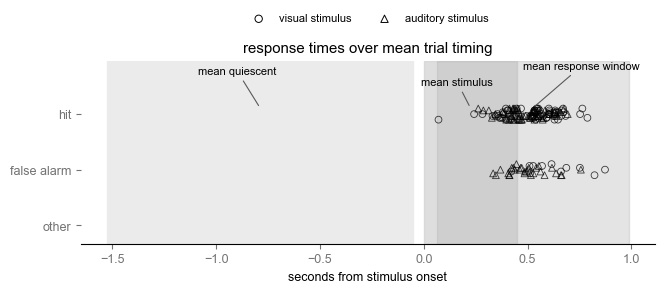

In [7]:
timing_summary = trials.select(
    [
        (pl.col("quiescent_start_time") - pl.col("stim_start_time"))
        .mean()
        .alias("quiescent_start"),
        (pl.col("quiescent_stop_time") - pl.col("stim_start_time"))
        .mean()
        .alias("quiescent_stop"),
        (pl.col("stim_stop_time") - pl.col("stim_start_time"))
        .mean()
        .alias("stimulus_stop"),
        (pl.col("response_window_start_time") - pl.col("stim_start_time"))
        .mean()
        .alias("response_window_start"),
        (pl.col("response_window_stop_time") - pl.col("stim_start_time"))
        .mean()
        .alias("response_window_stop"),
    ]
).row(0, named=True)

response_trials = (
    trials.filter(
        pl.col("is_response"),
        ~pl.col("is_catch"),
        pl.col("stim_name").is_in(["vis1", "vis2", "sound1", "sound2"]),
        pl.col("response_time").is_not_null(),
    )
    .with_columns(
        [
            (pl.col("response_time") - pl.col("stim_start_time")).alias(
                "response_latency"
            ),
            pl.when(pl.col("stim_name").str.starts_with("vis"))
            .then(pl.lit("visual"))
            .otherwise(pl.lit("auditory"))
            .alias("stimulus_modality"),
            pl.when(pl.col("is_hit"))
            .then(pl.lit("hit"))
            .when(pl.col("is_false_alarm"))
            .then(pl.lit("false alarm"))
            .otherwise(pl.lit("other response"))
            .alias("outcome"),
        ]
    )
)

fig, ax = plt.subplots(figsize=(7.4, 2.9))
intervals = [
    {
        "label": "mean quiescent",
        "start": timing_summary["quiescent_start"],
        "stop": timing_summary["quiescent_stop"],
        "color": "0.92",
        "alpha": 1.0,
        "text_x": -0.9,
        "text_y": 1.31,
    },
    {
        "label": "mean stimulus",
        "start": 0,
        "stop": timing_summary["stimulus_stop"],
        "color": "0.82",
        "alpha": 0.7,
        "text_x": 0.16,
        "text_y": 1.22,
    },
    {
        "label": "mean response window",
        "start": timing_summary["response_window_start"],
        "stop": timing_summary["response_window_stop"],
        "color": "0.70",
        "alpha": 0.35,
        "text_x": 0.76,
        "text_y": 1.35,
    },
]

for interval in intervals:
    ax.axvspan(
        interval["start"],
        interval["stop"],
        color=interval["color"],
        alpha=interval["alpha"],
        zorder=0,
    )
    center = (interval["start"] + interval["stop"]) / 2
    ax.annotate(
        interval["label"],
        xy=(center, 1.05),
        xytext=(interval["text_x"], interval["text_y"]),
        ha="center",
        va="bottom",
        fontsize=8,
        arrowprops={"arrowstyle": "-", "color": "0.35", "lw": 0.8},
    )

y_for_outcome = {"hit": 1.0, "false alarm": 0.55, "other response": 0.1}
marker_for_modality = {"visual": "o", "auditory": "^"}

for modality, marker in marker_for_modality.items():
    for outcome, y in y_for_outcome.items():
        data = response_trials.filter(
            (pl.col("stimulus_modality") == modality) & (pl.col("outcome") == outcome)
        )
        if data.is_empty():
            continue
        jitter = ((data["trial_index"].to_numpy() % 7) - 3) * 0.015
        ax.scatter(
            data["response_latency"].to_numpy(),
            np.full(data.height, y) + jitter,
            marker=marker,
            s=24,
            facecolors="none",
            edgecolors="black",
            linewidths=0.6,
            alpha=0.75,
            zorder=2,
        )

shape_handles = [
    ax.scatter([], [], marker="o", s=28, facecolors="none", edgecolors="black", linewidths=0.7, label="visual stimulus"),
    ax.scatter([], [], marker="^", s=28, facecolors="none", edgecolors="black", linewidths=0.7, label="auditory stimulus"),
]
ax.legend(
    handles=shape_handles,
    frameon=False,
    fontsize=8,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.18),
    ncol=2,
    borderaxespad=0,
)

ax.set_yticks([1.0, 0.55, 0.1])
ax.set_yticklabels(["hit", "false alarm", "other"])
ax.set_ylim(-0.05, 1.43)
ax.set_xlabel("seconds from stimulus onset")
ax.set_title("response times over mean trial timing")
ax.spines[["top", "right", "left"]].set_visible(False)
fig.subplots_adjust(top=0.74)
plt.show()


## Target-only behavior

To estimate response rates from trials directly, exclude instruction trials and scheduled-reward trials. The target identities are shown in separate panels, and point edge color shows which modality was rewarded in that block.


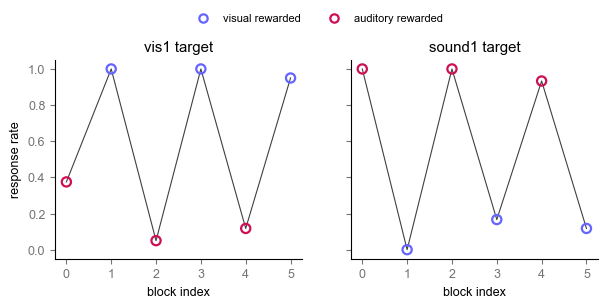

block_index,rewarded_modality,stim_name,n_trials,n_responses,response_rate
i64,str,str,u32,u32,f64
0,"""aud""","""sound1""",16,16,1.0
1,"""vis""","""sound1""",19,0,0.0
2,"""aud""","""sound1""",18,18,1.0
3,"""vis""","""sound1""",18,3,0.166667
4,"""aud""","""sound1""",15,14,0.933333
5,"""vis""","""sound1""",17,2,0.117647
0,"""aud""","""vis1""",16,6,0.375
1,"""vis""","""vis1""",20,20,1.0
2,"""aud""","""vis1""",20,1,0.05


In [35]:
from matplotlib.lines import Line2D

target_response_rates = (
    trials.filter(
        pl.col("stim_name").is_in(["vis1", "sound1"]),
        ~pl.col("is_instruction"),
        ~pl.col("is_reward_scheduled"),
    )
    .group_by("block_index", "rewarded_modality", "stim_name")
    .agg(
        pl.len().alias("n_trials"),
        pl.col("is_response").sum().alias("n_responses"),
    )
    .with_columns(response_rate=pl.col("n_responses") / pl.col("n_trials"))
    .sort(["stim_name", "block_index"])
)

fig, axes = plt.subplots(1, 2, figsize=(7, 2.8), sharey=True)

for ax, stim_name, title in zip(
    axes, ["vis1", "sound1"], ["vis1 target", "sound1 target"]
):
    data = target_response_rates.filter(pl.col("stim_name") == stim_name)
    ax.plot(data["block_index"], data["response_rate"], color="0.25", linewidth=0.8)
    for row in data.iter_rows(named=True):
        ax.scatter(
            row["block_index"],
            row["response_rate"],
            marker="o",
            s=44,
            facecolors="none",
            edgecolors=CONTEXT_COLORS[row["rewarded_modality"]],
            linewidths=1.6,
            zorder=2,
        )
    ax.set_title(title)
    ax.set_xlabel("block index")
    ax.set_xticks(block_summary["block_index"].to_list())
    ax.set_ylim(-0.05, 1.05)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("response rate")
fig.legend(
    handles=[
        Line2D(
            [],
            [],
            marker="o",
            linestyle="none",
            markerfacecolor="none",
            markeredgecolor=CONTEXT_COLORS["vis"],
            markeredgewidth=1.6,
            markersize=6,
            label="visual rewarded",
        ),
        Line2D(
            [],
            [],
            marker="o",
            linestyle="none",
            markerfacecolor="none",
            markeredgecolor=CONTEXT_COLORS["aud"],
            markeredgewidth=1.6,
            markersize=6,
            label="auditory rewarded",
        ),
    ],
    frameon=False,
    fontsize=8,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
)
fig.subplots_adjust(top=0.82)
plt.show()

target_response_rates


`/intervals/performance` provides richer block-level behavior metrics, including d' values and response rates for targets and non-targets. These are convenient for comparison, but it is still useful to know how the rates were derived from trials.


In [9]:
performance = (
    nwb_access.scan_table("/intervals/performance", session_id=SESSION_ID)
    .select(
        [
            "block_index",
            "rewarded_modality",
            "n_trials",
            "n_contingent_rewards",
            "hit_rate",
            "false_alarm_rate",
            "cross_modality_dprime",
            "vis_target_response_rate",
            "aud_target_response_rate",
            "vis_dprime",
            "aud_dprime",
        ]
    )
    .collect()
    .sort("block_index")
)

performance


block_index,rewarded_modality,n_trials,n_contingent_rewards,hit_rate,false_alarm_rate,cross_modality_dprime,vis_target_response_rate,aud_target_response_rate,vis_dprime,aud_dprime
i64,str,i64,f64,f64,f64,f64,f64,f64,f64,f64
0,"""aud""",77,21.0,1.0,0.428571,2.299392,0.375,1.0,-0.298005,0.830403
1,"""vis""",92,24.0,0.96,0.035088,3.688618,1.0,0.0,3.665192,-0.65638
2,"""aud""",91,22.0,0.956522,0.133333,3.356529,0.05,1.0,0.0,2.096996
3,"""vis""",80,21.0,0.954545,0.075472,2.658043,1.0,0.166667,3.28384,-0.024996
4,"""aud""",86,18.0,0.9,0.058824,2.468383,0.117647,0.933333,-0.026778,2.87477
5,"""vis""",89,23.0,0.92,0.037037,2.591903,0.95,0.117647,3.343003,0.024996


## One neural example: E-167

Unit `713655_2024-08-09_E-167` is in CP, passes `is_qc_pass`, passes `is_not_drift`, and has low `activity_drift`. The raster/PSTH helper filters to this unit before requesting spike times, so the notebook does not load every unit's spike vector.


In [14]:
unit_metadata = (
    nwb_access.scan_table("/units", unit_id=UNIT_ID, exclude_array_columns=True)
    .filter(pl.col("unit_id") == UNIT_ID)
    .select(
        [
            "unit_id",
            "location",
            "device_name",
            "is_qc_pass",
            "is_not_drift",
            "activity_drift",
            "firing_rate",
            "num_spikes",
        ]
    )
    .collect()
)

unit_metadata


unit_id,location,device_name,is_qc_pass,is_not_drift,activity_drift,firing_rate,num_spikes
str,str,str,bool,bool,f64,f64,f64
"""713655_2024-08-09_E-167""","""CP""","""20097906862""",true,true,0.05162,1.379626,10569.0


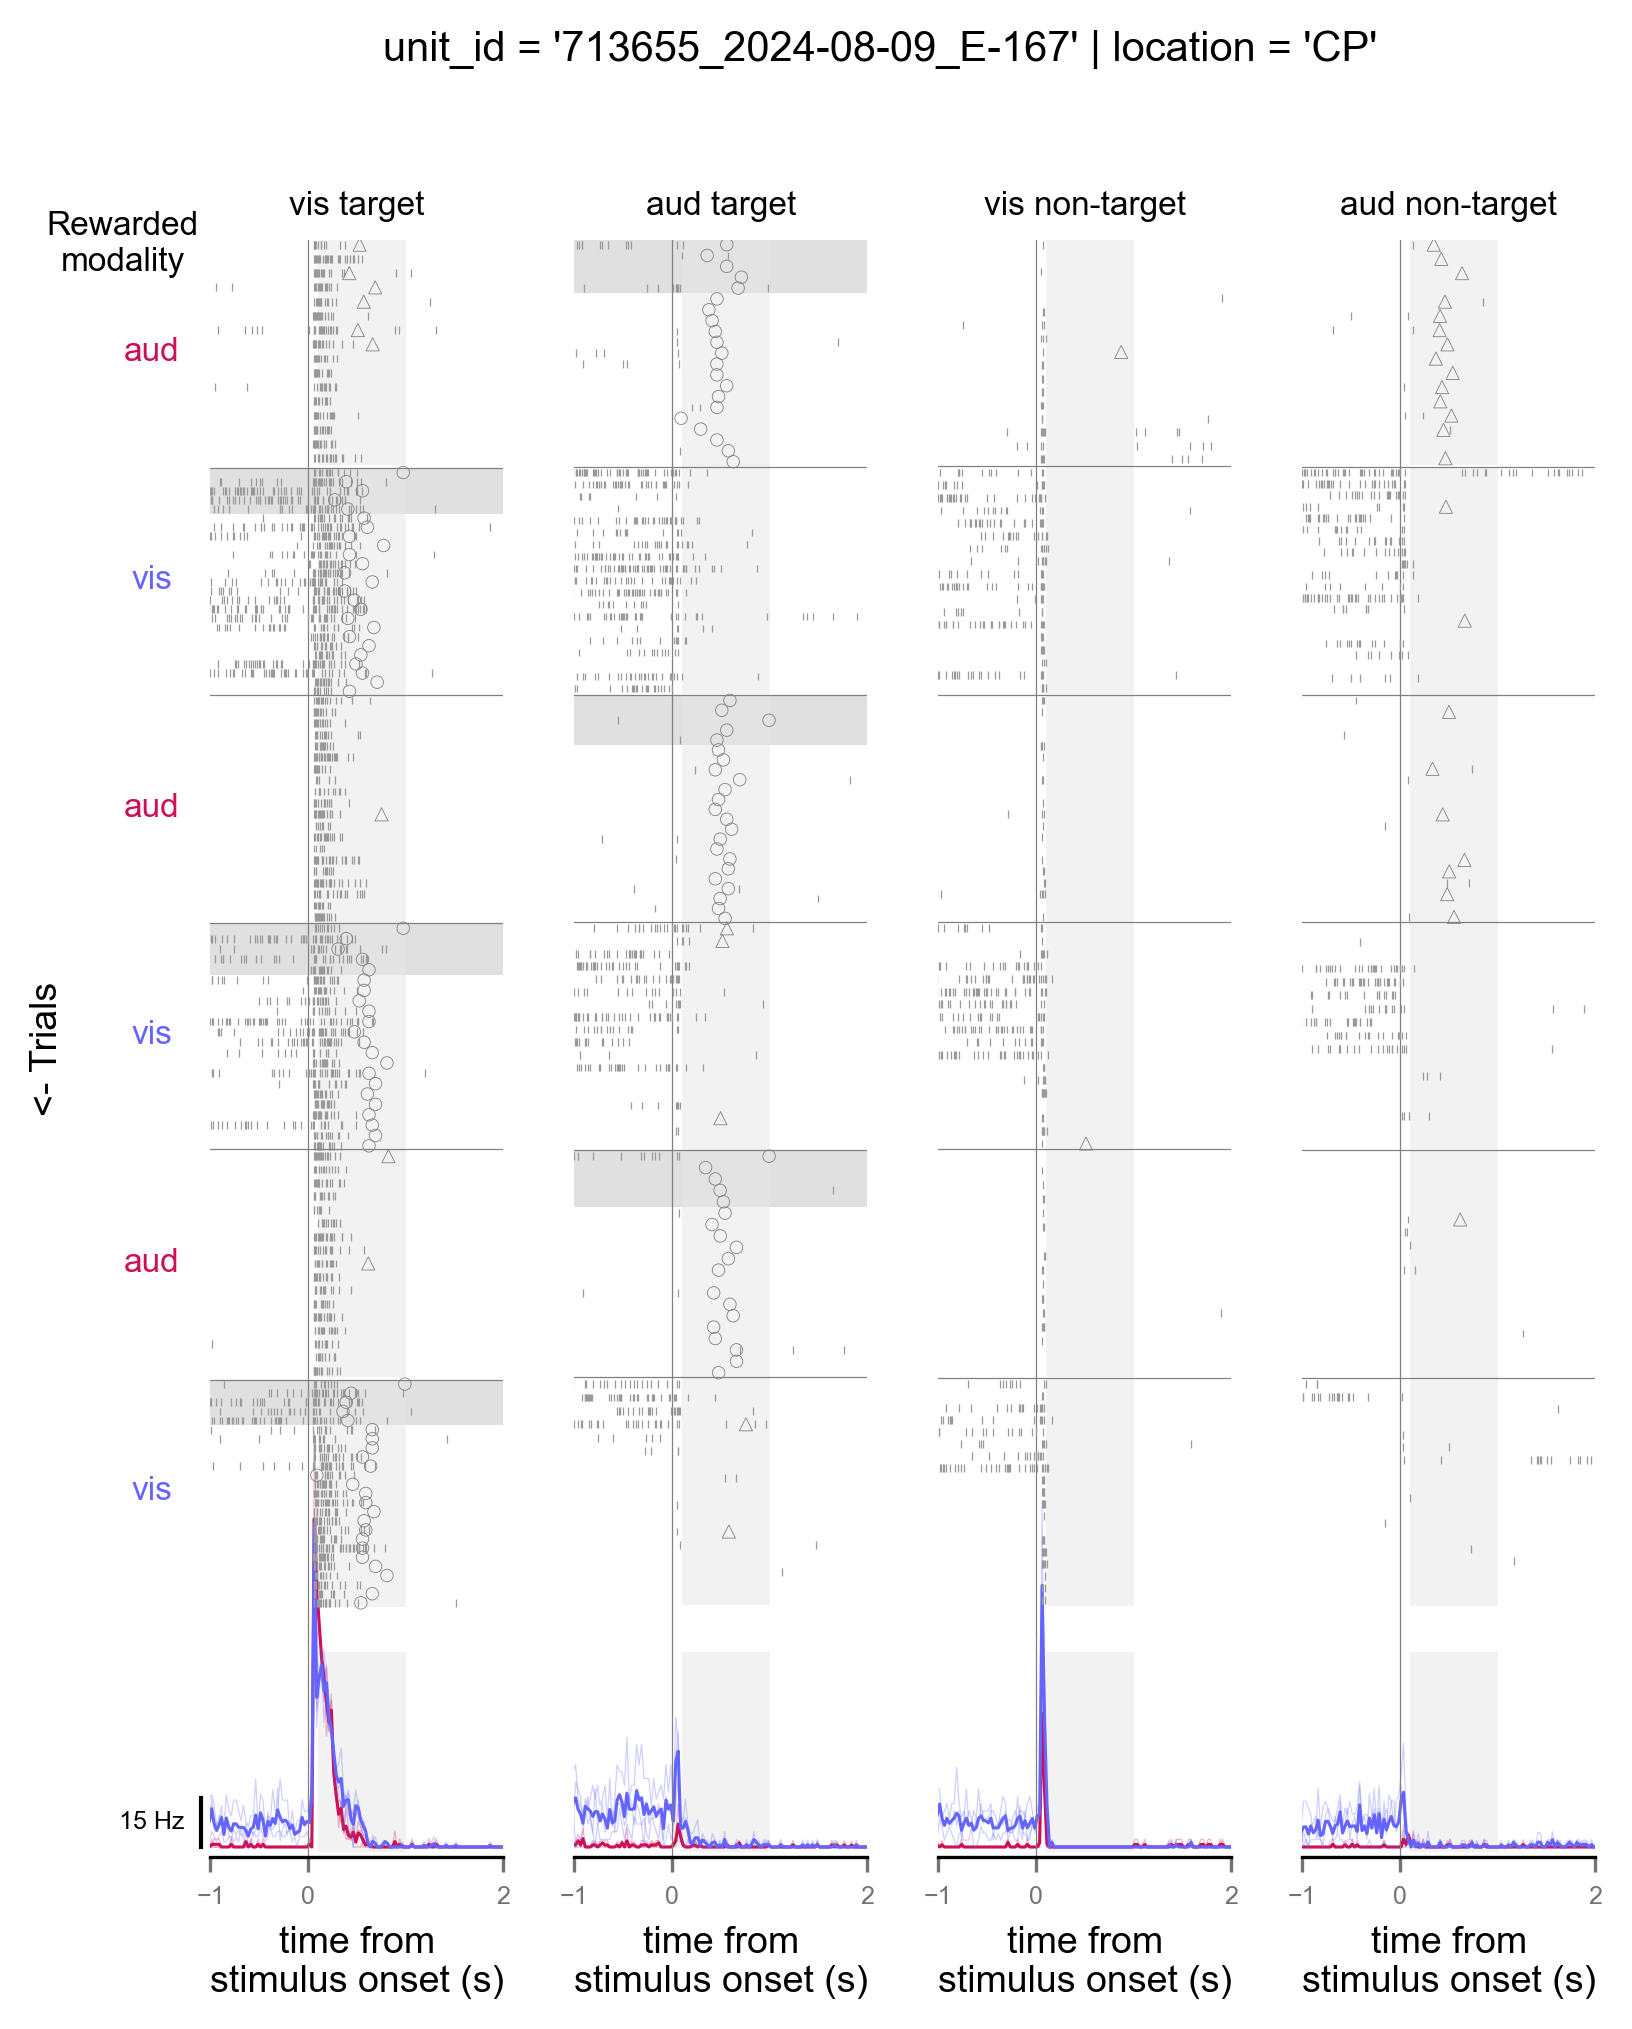

In [11]:
fig = unit_raster_psth_plot.plot(
    UNIT_ID,
    stim_names=("vis1", "sound1", "vis2", "sound2"),
    with_instruction_trial_whitespace=False,
    rewarded_context_colors=CONTEXT_COLORS,
    zarr=True,
)
plt.show()


## Running speed as a trial-aligned covariate

A neural response can be entangled with movement. As a simple covariate check, align running speed to stimulus onset for target trials, split columns by target identity, and group outcomes by row: hit plus correct reject in the top row, false alarm plus miss in the bottom row. Instruction and scheduled-reward trials are excluded here too.


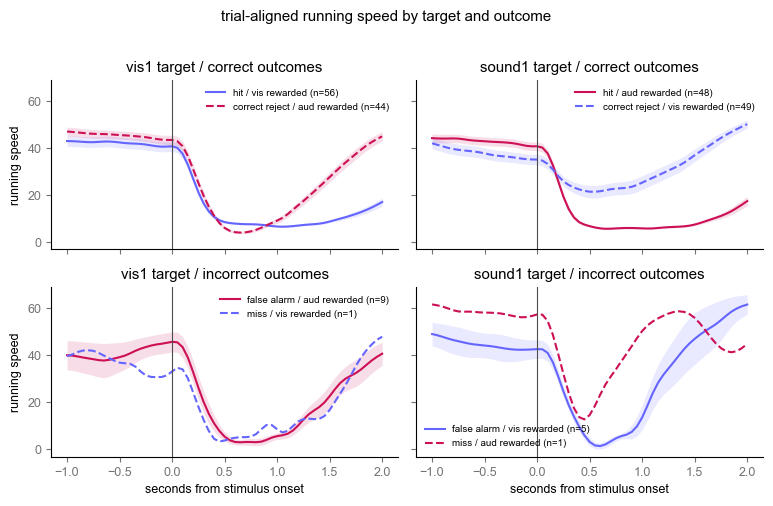

In [12]:
def align_signal_to_trials(
    signal: pl.DataFrame,
    *,
    time_column: str,
    value_column: str,
    value_name: str,
    trials_to_align: pl.DataFrame,
    time_grid: np.ndarray,
) -> list[dict]:
    signal = signal.filter(
        pl.col(time_column).is_not_null(),
        pl.col(value_column).is_not_null(),
        pl.col(time_column).is_finite(),
        pl.col(value_column).is_finite(),
    ).sort(time_column)
    signal_times = signal[time_column].to_numpy()
    signal_values = signal[value_column].to_numpy()

    aligned_rows = []
    for trial in trials_to_align.iter_rows(named=True):
        sample_times = trial["stim_start_time"] + time_grid
        if sample_times[0] < signal_times[0] or sample_times[-1] > signal_times[-1]:
            continue
        aligned_rows.append(
            {
                "stim_name": trial["stim_name"],
                "rewarded_modality": trial["rewarded_modality"],
                "outcome": trial["outcome"],
                value_name: np.interp(sample_times, signal_times, signal_values),
            }
        )
    return aligned_rows


def plot_aligned_signal_by_outcome(
    aligned_rows: list[dict],
    *,
    value_name: str,
    ylabel: str,
    title: str,
    time_grid: np.ndarray,
):
    fig, axes = plt.subplots(2, 2, figsize=(7.8, 4.9), sharex=True, sharey=True)
    stim_titles = {"vis1": "vis1 target", "sound1": "sound1 target"}
    outcome_rows = [
        ("correct outcomes", ["hit", "correct reject"]),
        ("incorrect outcomes", ["false alarm", "miss"]),
    ]
    outcome_styles = {
        "hit": "-",
        "correct reject": "--",
        "false alarm": "-",
        "miss": "--",
    }

    for row_idx, (row_title, outcomes) in enumerate(outcome_rows):
        for col_idx, stim_name in enumerate(["vis1", "sound1"]):
            ax = axes[row_idx, col_idx]
            for outcome in outcomes:
                for rewarded_modality in ["vis", "aud"]:
                    traces_for_group = [
                        row[value_name]
                        for row in aligned_rows
                        if row["stim_name"] == stim_name
                        and row["outcome"] == outcome
                        and row["rewarded_modality"] == rewarded_modality
                    ]
                    if not traces_for_group:
                        continue
                    traces = np.vstack(traces_for_group)
                    mean = traces.mean(axis=0)
                    sem = (
                        traces.std(axis=0, ddof=1) / np.sqrt(traces.shape[0])
                        if traces.shape[0] > 1
                        else np.zeros_like(mean)
                    )
                    color = CONTEXT_COLORS[rewarded_modality]
                    ax.plot(
                        time_grid,
                        mean,
                        color=color,
                        linestyle=outcome_styles[outcome],
                        label=(
                            f"{outcome} / {rewarded_modality} rewarded "
                            f"(n={traces.shape[0]})"
                        ),
                    )
                    ax.fill_between(
                        time_grid,
                        mean - sem,
                        mean + sem,
                        color=color,
                        alpha=0.14,
                        linewidth=0,
                    )

            ax.axvline(0, color="0.3", linewidth=0.8)
            ax.set_title(f"{stim_titles[stim_name]} / {row_title}")
            ax.spines[["top", "right"]].set_visible(False)
            if row_idx == 1:
                ax.set_xlabel("seconds from stimulus onset")
            if col_idx == 0:
                ax.set_ylabel(ylabel)
            ax.legend(frameon=False, fontsize=7, loc="best")

    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    return fig


time_grid = np.arange(-1.0, 2.01, 0.05)

target_trials_for_covariates = (
    trials.filter(
        pl.col("stim_name").is_in(["vis1", "sound1"]),
        ~pl.col("is_instruction"),
        ~pl.col("is_reward_scheduled"),
        (
            pl.col("is_hit")
            | pl.col("is_correct_reject")
            | pl.col("is_false_alarm")
            | pl.col("is_miss")
        ),
    )
    .with_columns(
        pl.when(pl.col("is_hit"))
        .then(pl.lit("hit"))
        .when(pl.col("is_correct_reject"))
        .then(pl.lit("correct reject"))
        .when(pl.col("is_false_alarm"))
        .then(pl.lit("false alarm"))
        .when(pl.col("is_miss"))
        .then(pl.lit("miss"))
        .alias("outcome")
    )
    .select(["trial_index", "stim_name", "rewarded_modality", "outcome", "stim_start_time"])
)

running = (
    nwb_access.scan_table("/processing/behavior/running_speed", session_id=SESSION_ID)
    .select(["timestamps", "data"])
    .collect()
)

running_aligned_rows = align_signal_to_trials(
    running,
    time_column="timestamps",
    value_column="data",
    value_name="running_speed",
    trials_to_align=target_trials_for_covariates,
    time_grid=time_grid,
)

plot_aligned_signal_by_outcome(
    running_aligned_rows,
    value_name="running_speed",
    ylabel="running speed",
    title="trial-aligned running speed by target and outcome",
    time_grid=time_grid,
)
plt.show()


## Pupil area as a trial-aligned covariate

The same four-outcome check can be repeated for pupil area. Pupil area comes from `/processing/behavior/eye_tracking`; bad pupil frames are excluded, and timestamps are read from `/acquisition/frametimes_eye_camera` because the eye-tracking table stores timestamp references rather than numeric timestamp values.


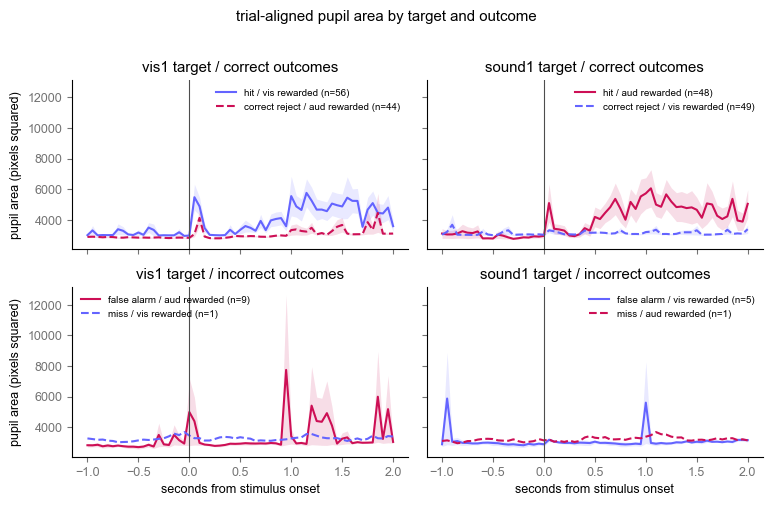

In [13]:
pupil_measurements = (
    nwb_access.scan_table("/processing/behavior/eye_tracking", session_id=SESSION_ID)
    .select(["pupil_area", "pupil_is_bad_frame"])
    .collect()
)

eye_frame_times = (
    nwb_access.scan_table("/acquisition/frametimes_eye_camera", session_id=SESSION_ID)
    .select(["timestamps"])
    .collect()
)

pupil = eye_frame_times.hstack(pupil_measurements).filter(
    pl.col("timestamps").is_finite(),
    pl.col("pupil_area").is_finite(),
    ~pl.col("pupil_is_bad_frame"),
)

pupil_aligned_rows = align_signal_to_trials(
    pupil,
    time_column="timestamps",
    value_column="pupil_area",
    value_name="pupil_area",
    trials_to_align=target_trials_for_covariates,
    time_grid=time_grid,
)

plot_aligned_signal_by_outcome(
    pupil_aligned_rows,
    value_name="pupil_area",
    ylabel="pupil area (pixels squared)",
    title="trial-aligned pupil area by target and outcome",
    time_grid=time_grid,
)
plt.show()


## Caveats and interpretation prompts

Instruction trials and scheduled-reward trials are useful for understanding the block transition, but they should usually be excluded from response-rate estimates because the animal is being cued and reward availability differs from ordinary trials.

This session uses a late-autoreward era task: a non-contingent reward can be scheduled near the end of the response window, but a correct response can cancel that scheduled reward and trigger a contingent reward earlier.

The E-167 raster is one example unit, not a population claim. Before interpreting context selectivity, ask whether the effect is robust across units and sessions, whether unit QC and low-drift filters were applied consistently, and whether movement or arousal covariates such as running speed and pupil area differ across the same trial groups.
